# Validation Data Overview

Display paired validation-set matrices for `SC`, `SC_r2t` corr, centroid distance, and `FC`. The notebook uses shared helpers from `data.data_viz` so plotting updates can be reloaded cleanly.

In [1]:
import sys
from pathlib import Path
import importlib

import numpy as np

REPO_ROOT = Path('/scratch/asr655/neuroinformatics/Conn2Conn')
sys.path.insert(0, str(REPO_ROOT))

import data.hcp_dataset as hcp_dataset
import data.data_viz as data_viz
importlib.reload(hcp_dataset)
importlib.reload(data_viz)

from data.hcp_dataset import HCP_Base
from data.data_viz import (
    compute_overview_ranges,
    get_validation_overview_matrices,
    make_validation_matrix_gif,
    plot_validation_matrix_overview,
)


In [2]:
PARCELLATION = 'Glasser'
SHUFFLE_SEED = 0
DATA_LOAD_MODE = 'precomputed'

base = HCP_Base(
    parcellation=PARCELLATION,
    shuffle_seed=SHUFFLE_SEED,
    source='SC',
    target='FC',
    data_load_mode=DATA_LOAD_MODE,
    write_manual_cache=False,
    expose_node_features=False,
)

VAL_INDICES = np.asarray(base.trainvaltest_partition_indices['val'])
VAL_SUBJECT_IDS = base.metadata_df.iloc[VAL_INDICES]['subject'].tolist()
ranges = compute_overview_ranges(base, val_indices=VAL_INDICES)

print(f'Parcellation: {PARCELLATION}')
print(f'Validation subjects: {len(VAL_INDICES)}')
print(f'First few validation subject ids: {VAL_SUBJECT_IDS[:5]}')


/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Parcellation: Glasser
Validation subjects: 79
First few validation subject ids: [100408, 101006, 103111, 104012, 104820]


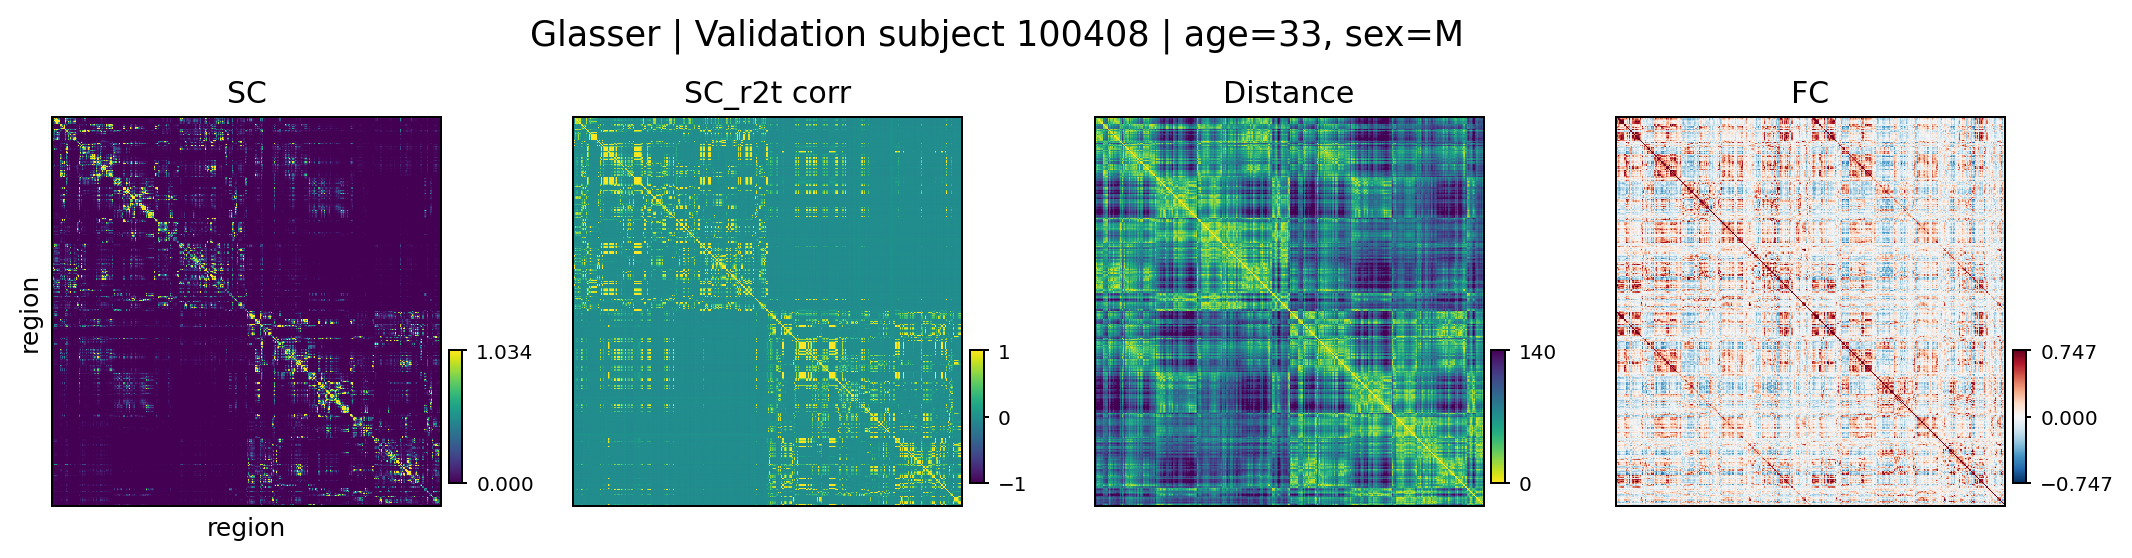

Validation subject 100408


In [3]:
# One validation subject (by validation-set position)
fig, axes, data = plot_validation_matrix_overview(
    base,
    val_position=0,
    ranges=ranges,
    header_metadata='age_sex_ethnicity'
)
print(data['label'])


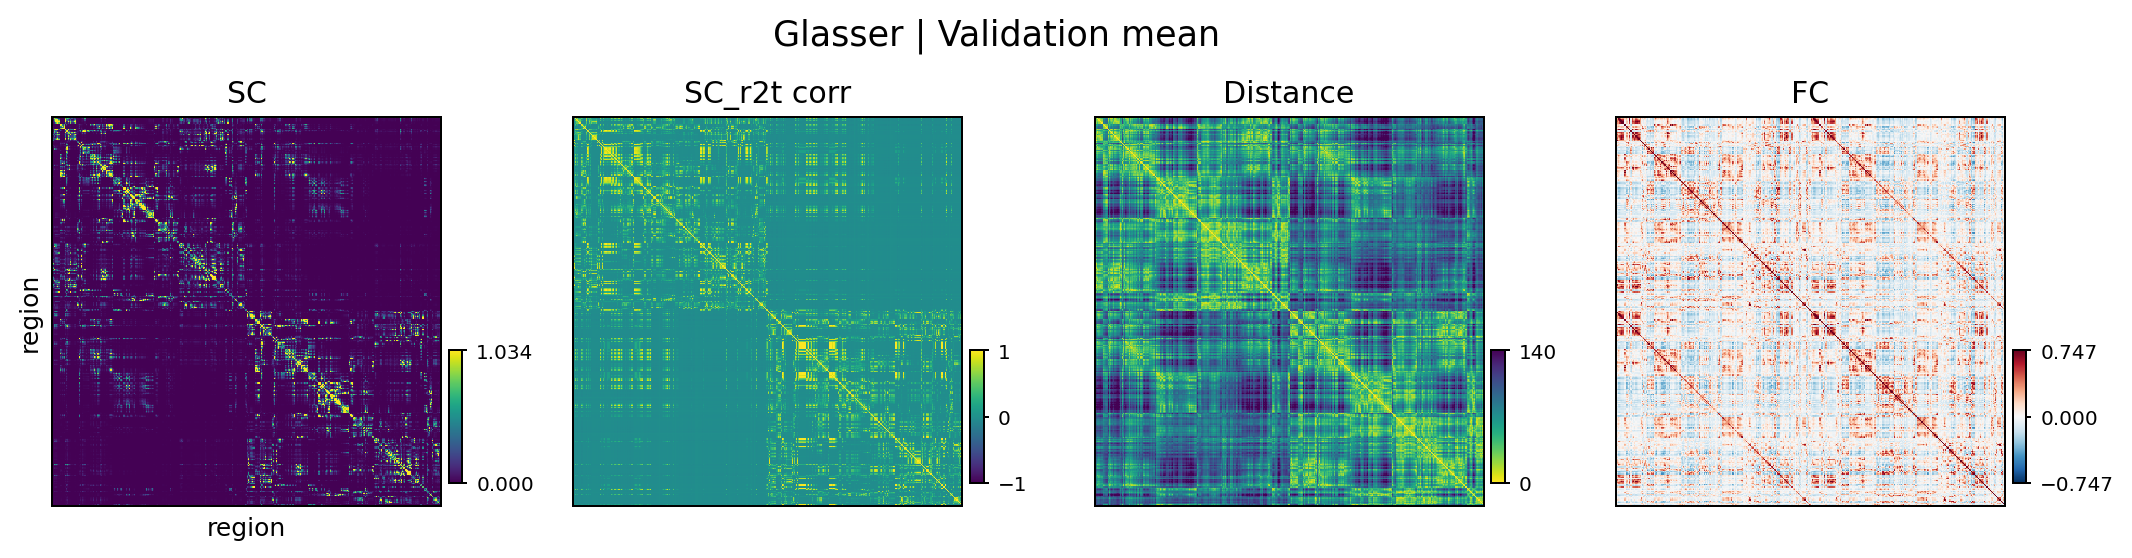

Validation mean


In [4]:
# Aggregate validation view: use aggregate='mean' or aggregate='median'
fig, axes, data = plot_validation_matrix_overview(
    base,
    aggregate='mean',
    ranges=ranges,
)
print(data['label'])


In [5]:
# # Preview the resolved matrices without plotting if you want to inspect raw arrays
# subject_data = get_validation_overview_matrices(base, val_position=0)
# for key in ['SC', 'SC_r2t_corr', 'distance', 'FC']:
#     print(key, subject_data[key].shape, float(subject_data[key].min()), float(subject_data[key].max()))


In [8]:
# GIF example
make_validation_matrix_gif(
    base,
    gif_path='results/figures/validation_matrix_overview_glasser100.gif',
    n_subjects=100,
    duration_ms=750,
    header_metadata='age_sex'
)

GIF saved to results/figures/validation_matrix_overview_glasser100.gif


PosixPath('results/figures/validation_matrix_overview_glasser100.gif')

In [27]:
# GIF example
make_validation_matrix_gif(
    base,
    gif_path='results/figures/validation_matrix_overview_glasser50.gif',
    n_subjects=50,
    duration_ms=1000,
)

GIF saved to results/figures/validation_matrix_overview_glasser50.gif


PosixPath('results/figures/validation_matrix_overview_glasser50.gif')

In [28]:
# GIF example
make_validation_matrix_gif(
    base,
    gif_path='results/figures/validation_matrix_overview_glasser20.gif',
    n_subjects=20,
    duration_ms=1250,
)

GIF saved to results/figures/validation_matrix_overview_glasser20.gif


PosixPath('results/figures/validation_matrix_overview_glasser20.gif')

In [29]:
# GIF example
make_validation_matrix_gif(
    base,
    gif_path='results/figures/validation_matrix_overview_glasser20_agesex.gif',
    n_subjects=20,
    duration_ms=1250,
    header_metadata='age_sex'
)

GIF saved to results/figures/validation_matrix_overview_glasser20_agesex.gif


PosixPath('results/figures/validation_matrix_overview_glasser20_agesex.gif')